In [1]:
import os
import glob

import numpy as np
import polars as pl
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc

In [2]:
WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/08_HepG2/'
OUTPUT_DIR = os.path.join(WORKING_DIR, 'output', 'common_histone')

In [3]:
# Check CUDA device
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


# Load Dataset

## Load the dataset with label value_1

In [4]:
# Load dataset
gene_pl = pl.read_parquet(os.path.join(WORKING_DIR, 'dataset', 'gene_w_label_value_1.parquet'))
gene_pl

gene_id,H3K4me3,H3K4me3_count,H3K9ac,H3K9ac_count,H3K9me3,H3K9me3_count,H3K27ac,H3K27ac_count,H3K27me3,H3K27me3_count,value_1,label
str,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,f64,i32
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_000006""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0888452,0
"""XLOC_000007""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,4.04743,1
"""XLOC_000008""","[0.0, 0.0, … 0.0]",6,"[0.0, 0.0, … 0.0]",3,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",2,"[0.0, 0.0, … 0.0]",0,26.7934,1
…,…,…,…,…,…,…,…,…,…,…,…,…
"""XLOC_030009""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_030012""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_030014""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0


In [5]:
# Check the label distribution
gene_pl.group_by("label").len()

label,len
i32,u32
1,11077
0,11077


## Reformat the data based on the histone markers used

In [6]:
markers = ['H3K4me3', 'H3K9me3', 'H3K27me3']

In [7]:
# Create dataframe based on histone marker permutation item
gene_perm_pl = gene_pl.with_columns(
    pl.struct(markers).map_elements(
        lambda x: [x[col_name] for col_name in markers],
        return_dtype = pl.List(pl.List(pl.Float64))
    )
    .alias('histone')
)

In [8]:
gene_perm_pl

gene_id,H3K4me3,H3K4me3_count,H3K9ac,H3K9ac_count,H3K9me3,H3K9me3_count,H3K27ac,H3K27ac_count,H3K27me3,H3K27me3_count,value_1,label,histone
str,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,f64,i32,list[list[f64]]
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0]]"
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0]]"
"""XLOC_000006""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0888452,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0]]"
"""XLOC_000007""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,4.04743,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0]]"
"""XLOC_000008""","[0.0, 0.0, … 0.0]",6,"[0.0, 0.0, … 0.0]",3,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",2,"[0.0, 0.0, … 0.0]",0,26.7934,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0]]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""XLOC_030009""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0]]"
"""XLOC_030012""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0]]"
"""XLOC_030014""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0]]"


# Data Preparation for Deep Learning

In [9]:
# Select X and y column
X = gene_perm_pl.select(pl.col('histone')).to_series().to_list()
y = gene_perm_pl.select(pl.col('label')).to_series().to_list()

In [10]:
# Convert to Numpy array
X = np.array(X)
y = np.array(y)

## Split the Data into train-validation-test set

In [11]:
# Split the dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.666, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [12]:
print("Train set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Train set shape: (7399, 3, 4000) (7399,)
Validation set shape: (7377, 3, 4000) (7377,)
Test set shape: (7378, 3, 4000) (7378,)


## Convert to Tensor

In [13]:
# Convert numpy arrays to PyTorch tensors
X_train = torch.from_numpy(X_train).float().unsqueeze(1).to(device)
X_val = torch.from_numpy(X_val).float().unsqueeze(1).to(device)
X_test = torch.from_numpy(X_test).float().unsqueeze(1).to(device)

y_train = torch.from_numpy(y_train).float().to(device)
y_val = torch.from_numpy(y_val).float().to(device)
y_test = torch.from_numpy(y_test).float().to(device)

## Create Data Loader

In [14]:
# Create DataLoaders
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Deep Classifier class

In [15]:
# Define DeepClassifer Class
class DeepClassifier(nn.Module):
    def __init__(self, input_dim = [5, 4000], out_channels = 50, conv_kernel_size = 10, max_pooling_kernel_size = 5):
        super(DeepClassifier, self).__init__()
        
        flatten_dim = out_channels * ((input_dim[1] - conv_kernel_size + 1) // max_pooling_kernel_size)

        self.conv = nn.Conv2d(1, out_channels, kernel_size=(input_dim[0], conv_kernel_size))
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d((1, max_pooling_kernel_size))
        self.dropout = nn.Dropout(0.5)
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(flatten_dim, 625)
        self.linear2 = nn.Linear(625, 125)
        self.linear3 = nn.Linear(125, 2)
        self.softmax = nn.LogSoftmax(dim=1)
        

    def forward(self, x):
        # Stage 1: filter bank -> squashing -> max pooling
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)

        # Stage 2: standar 2-layer neural network        
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.relu(x)
        x = self.linear3(x)
        x = self.softmax(x)
        return x

# Modeling

## Define model instance

In [16]:
n_rows_item = len(markers)
item_name = '-'.join(markers)
print(n_rows_item)
print(item_name)

3
H3K4me3-H3K9me3-H3K27me3


In [17]:
# Initialize the model
model = DeepClassifier(input_dim = [n_rows_item, 4000]).to(device)
criterion = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)
num_epochs = 100

# For tracking train and validation
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []

# For saving the best model
best_val_metric = float('-inf')
best_model_path = os.path.join(OUTPUT_DIR, "experiments", "model", f'{item_name}.pth')

## Training Phase

In [18]:
# Run the training and validation phase
for epoch in range(num_epochs):
    # Training phase
    model.train()  # Set the model to training mode
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    train_true_labels = []
    train_predicted_probs = []
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.cuda(), labels.type(torch.LongTensor).cuda())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        train_true_labels.extend(labels.cpu().numpy())
        train_predicted_probs.extend(predicted.cpu().numpy())
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    train_auc_score = roc_auc_score(train_true_labels, train_predicted_probs)
    
    train_losses.append(round(avg_train_loss, 4))
    train_accuracies.append(round(train_accuracy, 2))
    train_aucs.append(round(train_auc_score, 2))
    
    # Validation phase
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_metric = 0
    val_true_labels = []
    val_predicted_probs = []
    
    with torch.no_grad():  # Disable gradient computation
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs.cuda(), labels.type(torch.LongTensor).cuda())
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            val_true_labels.extend(labels.cpu().numpy())
            val_predicted_probs.extend(predicted.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total
    val_metric = val_correct / len(val_loader)

    # Save the best model
    if val_metric > best_val_metric:
        best_val_metric = val_metric
        torch.save(model.state_dict(), best_model_path)
        print(f"New best model saved with validation metric: {best_val_metric:.4f}")
    
    val_true_labels = np.array(val_true_labels)
    val_predicted_probs = np.array(val_predicted_probs)
    val_auc_score = roc_auc_score(val_true_labels, val_predicted_probs)

    val_losses.append(round(avg_val_loss, 4))
    val_accuracies.append(round(val_accuracy, 2))
    val_aucs.append(round(val_auc_score, 2))
    
    print(f'Epoch [{epoch+1}/{num_epochs}] - '
          f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, AUC: {train_auc_score:.2f} - '
          f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, AUC: {val_auc_score:.2f}')
print("Training finished!")

New best model saved with validation metric: 15.9654
Epoch [1/100] - [TRAIN] Loss: 0.6877, Accuracy: 49.99%, AUC: 0.50 - [VAL] Loss: 0.6762, Accuracy: 49.99%, AUC: 0.50
New best model saved with validation metric: 23.5887
Epoch [2/100] - [TRAIN] Loss: 0.6672, Accuracy: 57.81%, AUC: 0.58 - [VAL] Loss: 0.6509, Accuracy: 73.86%, AUC: 0.74
New best model saved with validation metric: 23.9913
Epoch [3/100] - [TRAIN] Loss: 0.6402, Accuracy: 74.90%, AUC: 0.75 - [VAL] Loss: 0.6221, Accuracy: 75.13%, AUC: 0.75
New best model saved with validation metric: 24.0606
Epoch [4/100] - [TRAIN] Loss: 0.6115, Accuracy: 75.82%, AUC: 0.76 - [VAL] Loss: 0.5966, Accuracy: 75.34%, AUC: 0.75
Epoch [5/100] - [TRAIN] Loss: 0.5863, Accuracy: 75.77%, AUC: 0.76 - [VAL] Loss: 0.5773, Accuracy: 75.30%, AUC: 0.75
Epoch [6/100] - [TRAIN] Loss: 0.5706, Accuracy: 75.82%, AUC: 0.76 - [VAL] Loss: 0.5659, Accuracy: 74.98%, AUC: 0.75
Epoch [7/100] - [TRAIN] Loss: 0.5586, Accuracy: 75.78%, AUC: 0.76 - [VAL] Loss: 0.5589, Accu

## Testing Phase

In [19]:
# Load the best model
best_model = DeepClassifier(input_dim = [n_rows_item, 4000]).to(device)
best_model.load_state_dict(torch.load(best_model_path))
best_model.eval()

# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = best_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_predictions.extend(predicted.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())

# Calculate evaluation metric
test_acc_score = round(accuracy_score(test_true_labels, test_predictions) * 100, 2)
print(f"Accuracy Score on test set: {test_acc_score:.2f} %")
test_auc_score = round(roc_auc_score(test_true_labels, test_predictions), 2)
print(f"AUC Score on test set: {test_auc_score:.2f}")

Accuracy Score on test set: 75.79 %
AUC Score on test set: 0.76


## Draw the training graph

In [39]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, kernel_size=10, pool_size=5):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 6))
    
    # Plot for training and validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'blue', label='Training Loss')
    plt.plot(epochs, val_losses, 'orange', label='Validation Loss')
    plt.title(f'Training and Validation Loss, kernel_size = {kernel_size}, pool_size = {pool_size}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot for training and validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'blue', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'orange', label='Validation Accuracy')
    plt.title(f'Training and Validation Accuracy, kernel_size = {kernel_size}, pool_size = {pool_size}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()

    img_name = f"{item_name}.png"
    plt.savefig(os.path.join(OUTPUT_DIR, 'img', 'train', img_name))
    
    plt.show()

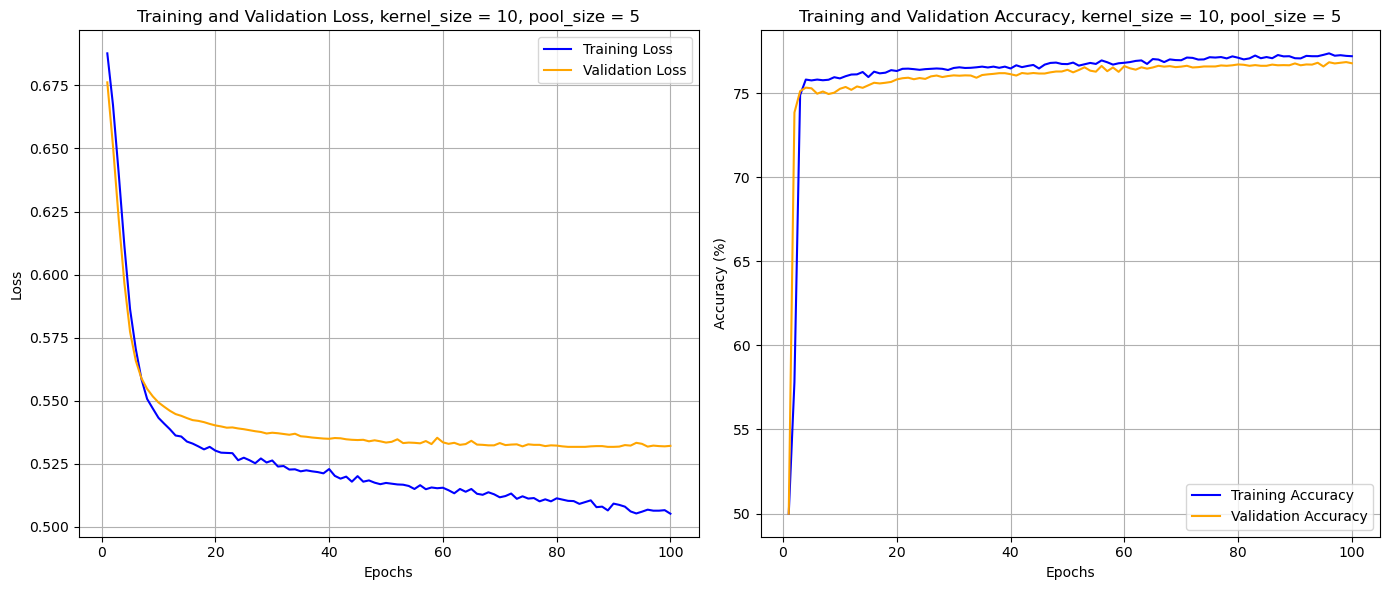

In [40]:
plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies)

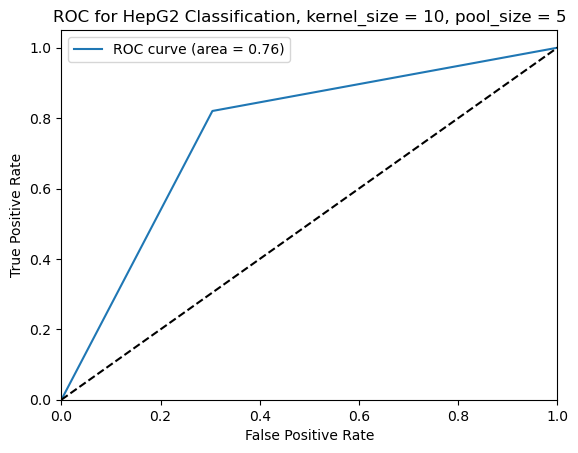

In [41]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_true_labels, test_predictions) 
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC for HepG2 Classification, kernel_size = 10, pool_size = 5')
plt.legend()

img_name = f"{item_name}.png"
plt.savefig(os.path.join(OUTPUT_DIR, 'img', 'roc', img_name))

plt.show()

# Saving the experiment results

## Detailed experiments

In [42]:
# Create dataframe from array
experiment_results = {
    'train_loss': train_losses,
    'train_accuracy': train_accuracies,
    'train_auc': train_aucs,
    'val_loss': val_losses,
    'val_accuracy': val_accuracies,
    'val_auc': val_aucs
}

In [43]:
experiment_pl = pl.DataFrame(experiment_results)

In [44]:
experiment_pl.write_csv(os.path.join(OUTPUT_DIR, 'experiments', 'details', f'{item_name}.csv'))

## Min, Avg, Max

In [45]:
def min_avg_max(lst):
    return round(min(lst), 2), round(sum(lst)/len(lst), 2), round(max(lst), 2)

In [46]:
train_loss_min, train_loss_avg, train_loss_max = min_avg_max(train_losses)
train_acc_min, train_acc_avg, train_acc_max = min_avg_max(train_accuracies)
train_auc_min, train_auc_avg, train_auc_max = min_avg_max(train_aucs)

print(f"{train_loss_min:.2f}, {train_loss_avg:.2f}, {train_loss_max:.2f}")
print(f"{train_acc_min}, {train_acc_avg}, {train_acc_max}")
print(f"{train_auc_min}, {train_auc_avg}, {train_auc_max}")

0.51, 0.53, 0.69
49.99, 76.25, 77.38
0.5, 0.76, 0.77


In [47]:
val_loss_min, val_loss_avg, val_loss_max = min_avg_max(val_losses)
val_acc_min, val_acc_avg, val_acc_max = min_avg_max(val_accuracies)
val_auc_min, val_auc_avg, val_auc_max = min_avg_max(val_aucs)

print(f"{val_loss_min:.2f}, {val_loss_avg:.2f}, {val_loss_max:.2f}")
print(f"{val_acc_min}, {val_acc_avg}, {val_acc_max}")
print(f"{val_auc_min}, {val_auc_avg}, {val_auc_max}")

0.53, 0.54, 0.68
49.99, 75.93, 76.86
0.5, 0.76, 0.77


In [48]:
print(f"{test_acc_score}, {test_auc_score}")

75.79, 0.76


In [49]:
# Prepare the output file
output_rows = []

output_rows.append([
    item_name,
    train_loss_min, train_loss_avg, train_loss_max,
    train_acc_min, train_acc_avg, train_acc_max,
    train_auc_min, train_auc_avg, train_auc_max,
    val_loss_min, val_loss_avg, val_loss_max,
    val_acc_min, val_acc_avg, val_acc_max,
    val_auc_min, val_auc_avg, val_auc_max,
    test_acc_score, test_auc_score
])

output_rows_df = pd.DataFrame(output_rows, 
    columns=[
        "item_name",
        "train_loss_min", "train_loss_avg", "train_loss_max",
        "train_acc_min", "train_acc_avg", "train_acc_max",
        "train_auc_min", "train_auc_avg", "train_auc_max",
        "val_loss_min", "val_loss_avg", "val_loss_max",
        "val_acc_min", "val_acc_avg", "val_acc_max",
        "val_auc_min", "val_auc_avg", "val_auc_max",
        "test_acc_score", "test_auc_score"
    ]
)

output_rows_df

,item_name,train_loss_min,train_loss_avg,train_loss_max,train_acc_min,train_acc_avg,train_acc_max,train_auc_min,train_auc_avg,train_auc_max,...,val_loss_avg,val_loss_max,val_acc_min,val_acc_avg,val_acc_max,val_auc_min,val_auc_avg,val_auc_max,test_acc_score,test_auc_score
0,H3K4me3-H3K9me3-H3K27me3,0.51,0.53,0.69,49.99,76.25,77.38,0.5,0.76,0.77,...,0.54,0.68,49.99,75.93,76.86,0.5,0.76,0.77,75.79,0.76


In [50]:
output_rows_df.to_csv(os.path.join(OUTPUT_DIR, "experiments", "min-avg-max", 
                              f"{item_name}.csv"), 
                 header=True, index=False)